In [0]:
%pip install catboost transformers cloudpickle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.7/96.7 MB 156.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 137.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 660.6/660.6 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.7/796.7 kB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 109.7 MB/s eta 0:00:00
  Attempting uninstall: regex
    Found existing installation: regex 2024.11.6
    Not uninstalling regex at /databricks/python3/lib/python3.12/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-ae359a23-d761-42dd-8cc6-fe70041d585d
    Can't uninstall 'regex'. No files were found to uninstall.
  Attempting uninstall: hf-xet
    Found existing installation: hf-xet 1.2.0
    Not uninstalling hf-xet at /databricks/python3/lib/python3.12/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-ae359a23-d761-42dd-8cc6-fe70041d585d
    Can't uninstall 

In [0]:


import logging
import cloudpickle
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

#  **Load pipeline and feature names with error handling**

In [0]:
# ============================================
# PRODUCTION: Load model artifacts from volume
# ============================================

VOLUME_PATH = "/Volumes/workspace/default/ml_artifacts/"

try:
    with open(VOLUME_PATH + "demand_pipeline.pkl", "rb") as f:
        pipeline = cloudpickle.load(f)
    logging.info("Pipeline loaded successfully from volume")
except FileNotFoundError:
    raise FileNotFoundError(f"Missing pipeline file: {VOLUME_PATH}demand_pipeline.pkl")

try:
    with open(VOLUME_PATH + "feature_names.pkl", "rb") as f:
        feature_names = cloudpickle.load(f)
    logging.info(f"Feature names loaded: {len(feature_names)} features from volume")
except FileNotFoundError:
    raise FileNotFoundError(f"Missing feature_names.pkl at {VOLUME_PATH}")

2026-05-01 11:43:41,646 - INFO - Pipeline loaded successfully from volume
2026-05-01 11:43:41,771 - INFO - Feature names loaded: 39 features from volume


# **load daily aggregated data with validation**

In [0]:
# ============================================
# Load and prepare daily sales data
# ============================================

INPUT_TABLE = "daily_aggregated_sales"

try:
    df = spark.table(INPUT_TABLE).toPandas()
    logging.info(f"Loaded {len(df)} rows from '{INPUT_TABLE}'")
except Exception as e:
    raise RuntimeError(f"Failed to read table '{INPUT_TABLE}': {e}")

if df.empty:
    raise ValueError(f"Table '{INPUT_TABLE}' is empty. Cannot generate forecast.")

# Ensure order_date is datetime and set as index
df['order_date'] = pd.to_datetime(df['order_date'])
df = df.set_index('order_date').sort_index()
logging.info(f"Date range: {df.index.min()} to {df.index.max()}")

2026-04-26 07:31:48,398 - INFO - Loaded 36 rows from 'daily_aggregated_sales'
2026-04-26 07:31:48,416 - INFO - Date range: 2023-01-31 00:00:00 to 2025-12-31 00:00:00


# **Prediction function with robust feature handling**

In [0]:
# ============================================
# Prediction function – handles missing columns
# ============================================

def predict_next_day(df_history):
    """
    Predict demand for the next day given historical daily data.
    Automatically handles missing features by filling with 0.
    """
    last_3 = df_history.tail(3).copy()
    next_date = df_history.index[-1] + timedelta(days=1)
    
    # Start with empty feature dict
    feat = {}
    
    # Basic time series features (must exist)
    feat['lag1'] = last_3['total_units_sold'].iloc[-1]
    feat['lag2'] = last_3['total_units_sold'].iloc[-2] if len(last_3) >= 2 else last_3['total_units_sold'].iloc[-1]
    feat['rolling_mean_2'] = last_3['total_units_sold'].iloc[-2:].mean() if len(last_3) >= 2 else last_3['total_units_sold'].mean()
    feat['rolling_mean_3'] = last_3['total_units_sold'].iloc[-3:].mean() if len(last_3) >= 3 else last_3['total_units_sold'].mean()
    feat['dayofweek'] = next_date.dayofweek
    feat['is_weekend'] = 1 if next_date.dayofweek >= 5 else 0
    feat['month'] = next_date.month
    
    # Copy all other columns from the last row (categorical proportions, etc.)
    for col in df_history.columns:
        if col not in ['total_units_sold', 'order_date']:
            feat[col] = last_3[col].iloc[-1]
    
    # Ensure all expected features are present – fill missing with 0
    for col in feature_names:
        if col not in feat:
            feat[col] = 0
            logging.warning(f"Feature '{col}' missing – filled with 0")
    
    # Create DataFrame in the correct order
    X_next = pd.DataFrame([feat])[feature_names]
    return pipeline.predict(X_next)[0]

#  **Generate next 7 days forecast**

In [0]:

FORECAST_HORIZON = 7
forecast_dates = []
forecast_values = []

temp = df.copy()
logging.info(f"Generating {FORECAST_HORIZON}-day forecast...")

for i in range(FORECAST_HORIZON):
    pred = predict_next_day(temp)
    next_date = temp.index[-1] + timedelta(days=1)
    forecast_dates.append(next_date)
    forecast_values.append(pred)
    
    # Append predicted row for next iteration (update lags)
    new_row = pd.DataFrame({'total_units_sold': [pred]}, index=[next_date])
    for col in df.columns:
        if col != 'total_units_sold':
            new_row[col] = temp[col].iloc[-1]
    temp = pd.concat([temp, new_row])
    
    logging.debug(f"Day {i+1}: {next_date.date()} -> {pred:.2f}")

logging.info(f"Forecast completed for {forecast_dates[0].date()} to {forecast_dates[-1].date()}")

# Build output DataFrame
forecast_df = pd.DataFrame({
    'forecast_date': forecast_dates,
    'predicted_units': forecast_values,
    'generated_at': pd.Timestamp.now()
})

# Display sample (interactive only)
if 'display' in globals():
    print("Next 7 days demand forecast:")
    display(forecast_df)

# Define output table name
OUTPUT_TABLE = "demand_forecast"

# Write to Spark table – using overwrite to replace previous forecast
spark.createDataFrame(forecast_df).write \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable(OUTPUT_TABLE)

logging.info(f"✅ Forecast saved to table '{OUTPUT_TABLE}' ({len(forecast_df)} rows)")

2026-04-26 07:38:49,262 - INFO - Generating 7-day forecast...
2026-04-26 07:38:49,530 - INFO - Forecast completed for 2026-01-01 to 2026-01-07


Next 7 days demand forecast:


forecast_date,predicted_units,generated_at
2026-01-01T00:00:00.000Z,26861.393674594667,2026-04-26T07:38:49.531Z
2026-01-02T00:00:00.000Z,26856.642516123622,2026-04-26T07:38:49.531Z
2026-01-03T00:00:00.000Z,26778.1109212799,2026-04-26T07:38:49.531Z
2026-01-04T00:00:00.000Z,26782.545946400303,2026-04-26T07:38:49.531Z
2026-01-05T00:00:00.000Z,26792.115873486087,2026-04-26T07:38:49.531Z
2026-01-06T00:00:00.000Z,26782.545946400303,2026-04-26T07:38:49.531Z
2026-01-07T00:00:00.000Z,26782.545946400303,2026-04-26T07:38:49.531Z


In [0]:
# Write to Spark table – using overwrite to replace previous forecast
# (If you need history, consider adding a partition by generation date)
spark.createDataFrame(forecast_df).write \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable(OUTPUT_TABLE)

logging.info(f"✅ Forecast saved to table '{OUTPUT_TABLE}' ({len(forecast_df)} rows)")

2026-04-26 07:40:28,762 - INFO - ✅ Forecast saved to table 'demand_forecast' (7 rows)


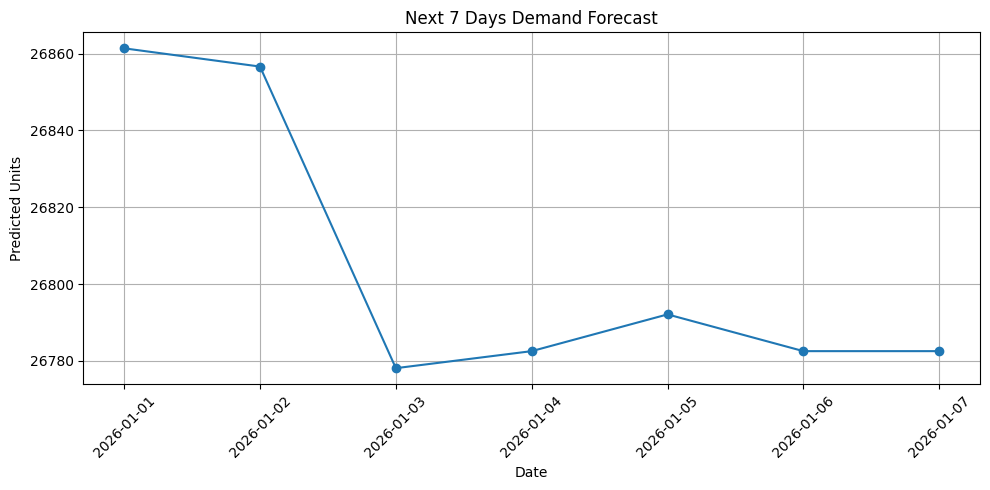

In [0]:
# ============================================
# Optional: Plot forecast (only if matplotlib is available)
# ============================================

try:
    plt.figure(figsize=(10, 5))
    plt.plot(forecast_df['forecast_date'], forecast_df['predicted_units'], marker='o', linestyle='-')
    plt.title('Next 7 Days Demand Forecast')
    plt.xlabel('Date')
    plt.ylabel('Predicted Units')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    logging.info("Forecast plot generated")
except Exception as e:
    logging.warning(f"Could not generate plot: {e}")